In [ ]:
# Ensure you have at least 2GB free space in Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Project setup
import os
PROJECT_DIR = "/content/drive/MyDrive/DL_Group_MGI1"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working in:", os.getcwd())

# Install dependencies
!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image wandb iterative-stratification torchmetrics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Run this everytime you update something in the repo!
REPO = "https://github.com/gabrielcastrob/Deep_learning_WUR"

# if project directory is empty clone the repo, otherwise pull the latest changes
if not os.listdir(PROJECT_DIR):
    !git clone {REPO} {PROJECT_DIR}
else:
    !git -C {PROJECT_DIR} pull

%cd {PROJECT_DIR}
print("Working in:", os.getcwd())

Already up to date.
/content
Working in: /content/drive/MyDrive/DL_Group_MGI1


In [ ]:
import random, shutil, zipfile
import subprocess
from pathlib import Path
from PIL import Image
import glob
import importlib
  


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms
import torchvision.models as tvm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, average_precision_score, hamming_loss
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import pytorch_lightning as L
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

from pytorch_lightning.loggers import CSVLogger
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import torchmetrics
import re 

# utility functions
import utils


L.seed_everything(42, workers=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
print("Accelerator:", DEVICE)
if DEVICE == "gpu":
    print("GPU:", torch.cuda.get_device_name(0))

INFO:lightning_fabric.utilities.seed:Seed set to 42


Accelerator: gpu
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


Download dataset

In [59]:
"Download the UCMerced Land Use dataset if not already present. "
"The dataset will be saved in the 'ucmdata' directory. "
if not os.path.exists('ucmdata'):
    subprocess.run(['git', 'clone', 'https://git.wur.nl/lobry001/ucmdata.git'])
    os.chdir('ucmdata')

    with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zip_ref:
        zip_ref.extractall('UCMImages')

    shutil.move('UCMImages/UCMerced_LandUse/Images', '.')
    shutil.rmtree('UCMImages')
    os.remove('README.md')
    os.remove('UCMerced_LandUse.zip')
UCM_images_path = "/ucmdata/Images/"
Multilabels_path = "/ucmdata/LandUse_Multilabeled.txt"

print(os.listdir('.'))

# After git pull, reload utils to get the latest changes without restarting the notebook
importlib.reload(utils)

['.git', 'GRS_34806_MGI_Project.ipynb', 'LICENSE', 'Level2_ResNet50_UCM', 'README.md', 'notebooks', 'ucmdata', '__pycache__', 'wandb', 'outputs', 'utils.py']


<module 'utils' from '/content/drive/MyDrive/DL_Group_MGI1/utils.py'>

Data split and augmentation

In [60]:
# Full dataloader test 
# Can take a long time (4.5min on Colab GPU T4)
from utils import build_dataloaders

train_loader, val_loader, test_loader, classes, pos_w = build_dataloaders(
    root_dir = "ucmdata",
    label_file = "LandUse_Multilabeled.txt",
    image_size = (224, 224),
    batch_size = 32,
    num_workers = 2,
    val_frac = 0.15,
    test_frac = 0.15,
    seed = 42,
    image_ext = ".tif",
)

train_labels = torch.cat([labels for _, labels in train_loader]).numpy()
val_labels = torch.cat([labels for _, labels in val_loader]).numpy()
test_labels = torch.cat([labels for _, labels in test_loader]).numpy()

# Create a dataframe and export to csv that appends the class frequencies
import numpy as np
distribution_df = pd.DataFrame({
    "class": classes,
    "train_freq": train_labels.sum(axis=0),
    "val_freq": val_labels.sum(axis=0),
    "test_freq": test_labels.sum(axis=0),
})
distribution_df.to_csv("outputs/Balanced_class_distribution.csv", index=False)


Initialize WANDB

Hyperparameters 

In [ ]:
# Define hyperparameters
PRETRAINED_MODEL = "resnet50"
NUM_CLASSES = len(classes)
MAX_EPOCHS = 25
EARLYSTOPPING_EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 1e-5
run_count = 3


Load and train model

In [50]:
def build_resnet50(num_classes):
    weights = tvm.ResNet50_Weights.IMAGENET1K_V2
    model = tvm.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

backbone = build_resnet50(num_classes=NUM_CLASSES)
n_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
print(f"ResNet-50 trainable parameters: {n_params:,}  |  output logits: {NUM_CLASSES}")

ResNet-50 trainable parameters: 23,542,865  |  output logits: 17


Training

In [51]:
from utils import LightningModuleMultilabel 

lit_model = LightningModuleMultilabel(model=backbone, num_classes=NUM_CLASSES,
                                      lr=LR, weight_decay=WEIGHT_DECAY, max_epochs=MAX_EPOCHS, pos_weight=pos_w)
# Callbacks 
checkpoint_cb = ModelCheckpoint(
    dirpath="outputs/checkpoints",
    filename="resnet50-multilabel-best-{epoch:02d}-{val_f1:.4f}",
    monitor="val_f1", mode="max", save_top_k=1, save_weights_only=True,
)

early_stopping = EarlyStopping(
            monitor="val_f1",  
            patience=EARLYSTOPPING_EPOCHS,        # Number of epochs with no improvement
            mode="max",        # Maximize F1 score
            verbose=True
            )

# Logger to plot later
csv_logger = CSVLogger(save_dir="outputs/logs", name="resnet50_multilabel")

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    callbacks=[early_stopping, checkpoint_cb],
    logger=csv_logger,
    log_every_n_steps=10,
)
trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet                     │ 23.5 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94                                                                         
Modules in train mode: 159                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_f1 improved by 0.001 >= min_delta = 0.0. New best score: 0.937


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_f1 improved by 0.006 >= min_delta = 0.0. New best score: 0.943


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_f1 improved by 0.001 >= min_delta = 0.0. New best score: 0.944


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_f1 improved by 0.002 >= min_delta = 0.0. New best score: 0.946


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.


Final classification on test data

In [52]:
# Evaluate using the best checkpoint
trainer.test(lit_model, dataloaders=test_loader, ckpt_path="best")

best_path = checkpoint_cb.best_model_path
print(f"Best checkpoint: {best_path}")
lit_model = LightningModuleMultilabel.load_from_checkpoint(best_path, model=lit_model.model)

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnet50-multilabel-best-epoch=18-val_f1=0.9457.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnet50-multilabel-best-epoch=18-val_f1=0.9457.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9595353603363037     │
│          test_f1          │    0.9436820149421692     │
│         test_loss         │    0.12311072647571564    │
│         test_map          │    0.9796864986419678     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnet50-multilabel-best-epoch=18-val_f1=0.9457.ckpt


In [53]:

# Collect probs, preds and ground-truth for downstream analysis
preds_out = trainer.predict(lit_model, dataloaders=test_loader)
test_probs  = torch.cat([b["probs"]  for b in preds_out], dim=0).cpu().numpy()
test_preds  = torch.cat([b["preds"]  for b in preds_out], dim=0).cpu().numpy()
test_labels = torch.cat([b["labels"] for b in preds_out], dim=0).cpu().numpy()


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [54]:
from utils import compute_test_metrics

# Usage
metrics = compute_test_metrics(test_preds, test_labels, test_probs)

# Print metrics
print(f"\nTest accuracy   : {metrics['accuracy']:.4f}")
print(f"Test macro F1   : {metrics['macro_f1']:.4f}")
print(f"Test micro F1   : {metrics['micro_f1']:.4f}")
print(f"Test samples F1 : {metrics['samples_f1']:.4f}")
print(f"Test macro mAP  : {metrics['macro_map']:.4f}")
print(f"Hamming loss    : {metrics['hamming_loss']:.4f}")
print(f"Exact-match acc : {metrics['subset_acc']:.4f}")

# Export and append to a csv of the metrics f1 score of many other models and runs for comparison and plotting later
from utils import append_metrics_to_csv

append_metrics_to_csv(metrics, model_name="ML_ResNet50_Balanced")




Test accuracy   : 0.9595
Test macro F1   : 0.9437
Test micro F1   : 0.9002
Test samples F1 : 0.9076
Test macro mAP  : 0.9797
Hamming loss    : 0.0405
Exact-match acc : 0.5223


Visualize

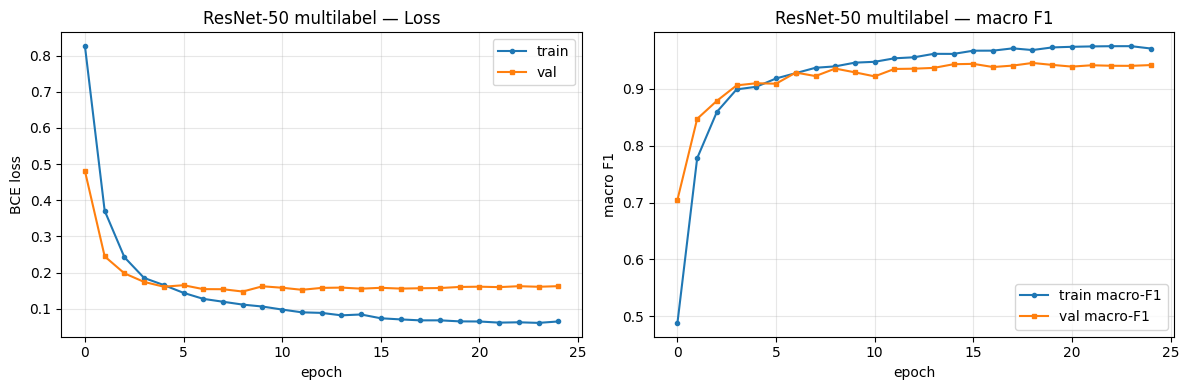

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'ResNet-50 multilabel — Loss'}, xlabel='epoch', ylabel='BCE loss'>,
        <Axes: title={'center': 'ResNet-50 multilabel — macro F1'}, xlabel='epoch', ylabel='macro F1'>],
       dtype=object))

In [55]:
# Usage
from utils import plot_training_curves
plot_training_curves(csv_logger, model_name="ResNet-50 multilabel", 
                     save_path=None)

Saved per-class metrics plot to: outputs/resnet50_multilabel_per_class.png


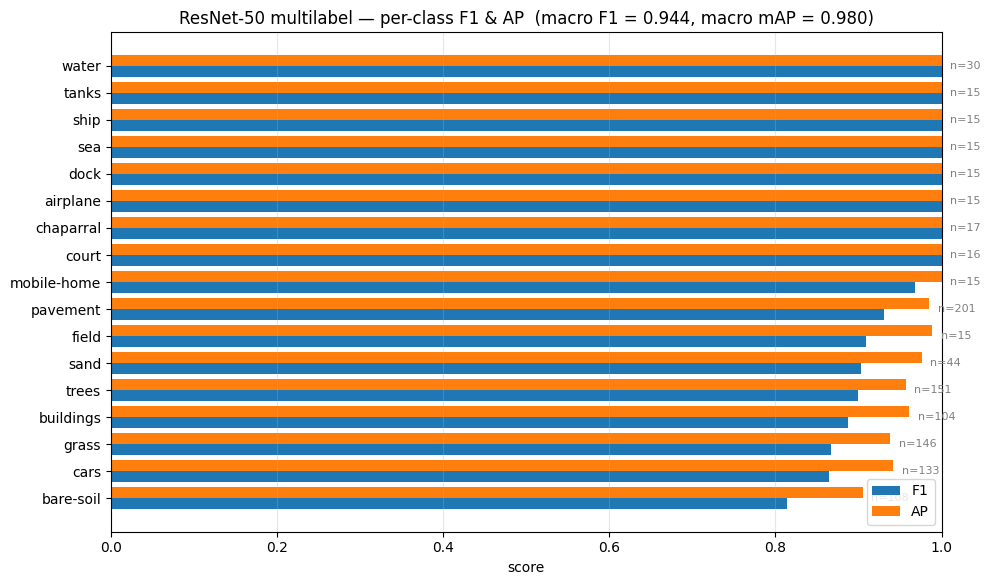


Per-class Summary:
      class  positives     F1     AP
  bare-soil        108 0.8139 0.9054
       cars        133 0.8643 0.9418
      grass        146 0.8669 0.9384
  buildings        104 0.8868 0.9613
      trees        151 0.8997 0.9571
       sand         44 0.9032 0.9766
      field         15 0.9091 0.9889
   pavement        201 0.9310 0.9851
mobile-home         15 0.9677 1.0000
      court         16 1.0000 1.0000
  chaparral         17 1.0000 1.0000
   airplane         15 1.0000 1.0000
       dock         15 1.0000 1.0000
        sea         15 1.0000 1.0000
       ship         15 1.0000 1.0000
      tanks         15 1.0000 1.0000
      water         30 1.0000 1.0000
Saved summary table to: outputs/resnet50_multilabel_per_class.csv


In [56]:
from utils import plot_per_class_metrics

# Usage
fig, ax, summary_df = plot_per_class_metrics(
    test_labels=test_labels,
    test_preds=test_preds,
    test_probs=test_probs,
    classes=classes,
    macro_f1=metrics['macro_f1'],
    macro_map=metrics['macro_map'],
    model_name="ResNet-50 multilabel",
    save_path="outputs/resnet50_multilabel_per_class.png",
    csv_output="outputs/resnet50_multilabel_per_class.csv"
)

Examples of images

Saved prediction grid to: outputs/resnet50_multilabel_predictions_grid.png


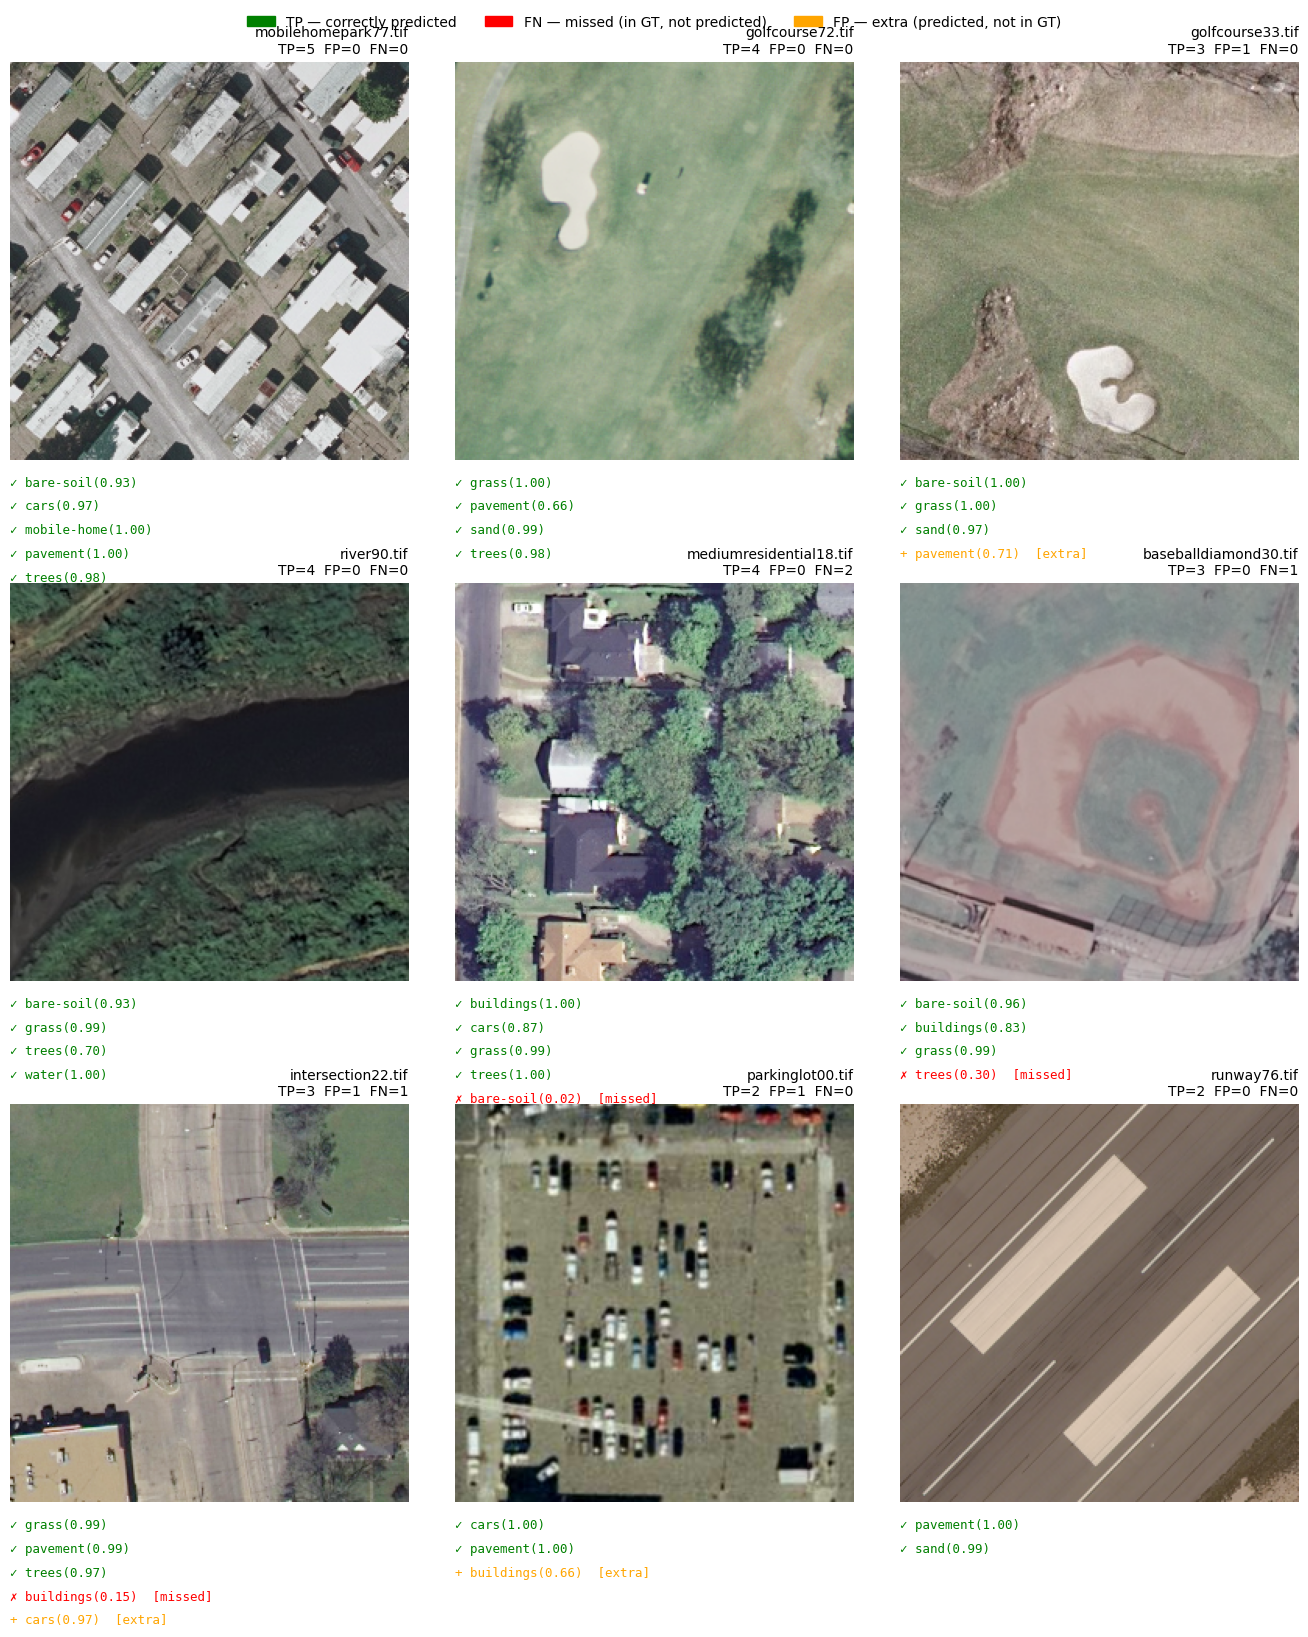

In [57]:

from utils import plot_prediction_grid
fig = plot_prediction_grid(
    test_preds=test_preds,
    test_labels=test_labels,
    test_probs=test_probs,
    classes=classes,
    test_loader=test_loader,
    root_dir="ucmdata",
    label_file="LandUse_Multilabeled.txt",
    n_show=9,
    seed=4,
    save_path="outputs/resnet50_multilabel_predictions_grid.png"
)